# Galaxy Bias Analysis: P-Millennium GALFORM Snapshots

Investigate galaxy clustering bias by comparing galaxy and dark matter two-point correlation functions across P-Millennium merger tree subvolumes.

In [9]:
# Ensure local package path is first
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import libraries
import numpy as np
import matplotlib.pyplot as plt
from galform_analysis.config import get_base_dir
import importlib

# Reload to pick up code changes
import galform_analysis.analysis.correlation.galaxy_bias as bias_module

importlib.reload(bias_module)

# Import functions
from galform_analysis.analysis.correlation import (
    compute_galaxy_bias,
    avg_galaxy_bias_over_subvolumes,
 )

base_dir = get_base_dir()

# Merger tree base directory (edit if needed)
PMILLENNIUM_BASE = Path("/cosma5/data/jch/Galform/Merger_Trees/P-Millennium/Updated_Trees/all_snaps")
SNAP_NUM_BY_IZ = {
    207: 269,  # iz207 -> snapshot 269 (z = 0.496)
    271: 271,  # iz271 -> snapshot 271 (z = 0.0)
}

def tree_file_for(iz_num: int, ivol: int) -> Path:
    snap_num = SNAP_NUM_BY_IZ.get(iz_num)
    if snap_num is None:
        raise KeyError(f"No tree snapshot mapping for iz{iz_num}. Add to SNAP_NUM_BY_IZ.")
    return PMILLENNIUM_BASE / f"treedir_{snap_num}" / f"tree_{snap_num}.{ivol}.hdf5"

# Plotting defaults
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

## Single Subvolume Example

In [ ]:
# Parameters for analysis
example_snapshot = 'iz207'
example_ivol = 100
snap_path = str(base_dir / example_snapshot)

# Define bin edges
rbins = np.logspace(np.log10(0.1), np.log10(50.0), 20)

# Optional: apply minimum halo mass cut
mhalo_min = 1e11  # Msun

# DM halo tree file
tree_file = tree_file_for(207, example_ivol)

print(f"Computing galaxy bias for {example_snapshot}, subvolume {example_ivol}")
print(f"Mass cut: M_halo >= {mhalo_min:.1e} Msun\n")

result = compute_galaxy_bias(
    iz_path=snap_path,
    ivol=example_ivol,
    tree_file=str(tree_file),
    rbins=rbins,
    nthreads=4,
    mhalo_min=mhalo_min,
 )

if result is not None:
    print(f"✓ Data computed successfully")
    print(f"  Redshift: {result.attrs.get('z'):.4f}")
    print(f"  N_galaxies: {result.attrs.get('ngal')}")
    print(f"  N_halos: {result.attrs.get('nhalo')}")
    print(f"  Galaxies per halo: {result.attrs.get('ngal') / result.attrs.get('nhalo'):.2f}")
else:
    print("✗ Failed to compute galaxy bias")

Computing galaxy bias for iz207, subvolume 100
Mass cut: M_halo >= 1.0e+11 Msun



/tmp/ipykernel_2871009/1395973638.py:8: RuntimeWarning: invalid value encountered in sqrt
  bias = np.sqrt(xi_gal / xi_dm)



   r [Mpc/h]      ξ_gal(r)       ξ_DM(r)      bias
--------------------------------------------------
        0.12   1502.696147  21469.476395     0.265
        0.17    848.886878  17167.888250     0.222
        0.23    482.045247  12065.452056     0.200
        0.32    236.488674   6406.112076     0.192
        0.44    113.567692   3247.794167     0.187
        0.61     50.711762   1692.824910     0.173
        0.85     20.260176    819.905796     0.157
        1.18      9.610138    173.622658     0.235
        1.63      3.942408     23.104865     0.413
        2.28      2.083384      4.064433     0.716
        4.43      0.005281      1.819700     0.054
        8.51      0.059229      0.547210     0.329
       11.83     -0.023308     -0.043979     0.728
       22.78     -0.003751     -0.018992     0.444


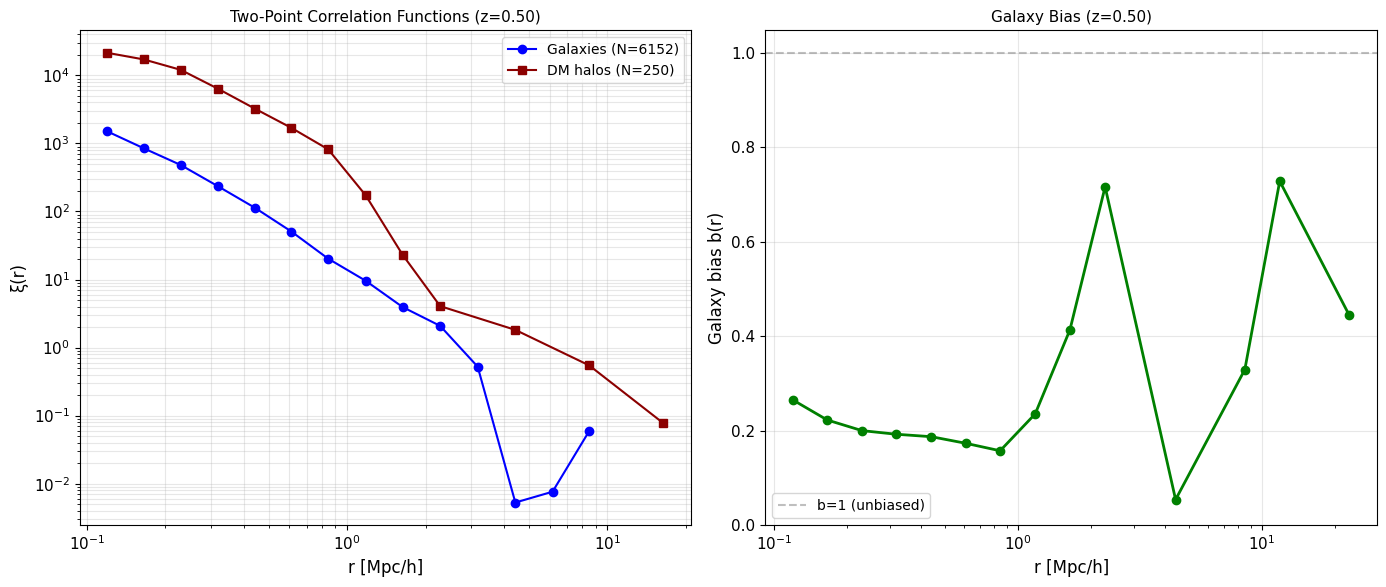

In [ ]:
# Plot single subvolume galaxy bias results
if result is not None:
    r = result['r'].to_numpy()
    xi_gal = result['xi_gal'].to_numpy() - 1  # Convert from (1+xi) to xi
    xi_dm = result['xi_dm'].to_numpy() - 1
    
    # Compute bias correctly: b(r) = sqrt(xi_gal / xi_dm)
    bias = np.sqrt(xi_gal / xi_dm)
    
    # Create summary table
    mask = np.isfinite(bias)
    print(f"\n{'r [Mpc/h]':>12}  {'ξ_gal(r)':>12}  {'ξ_DM(r)':>12}  {'bias':>8}")
    print("-" * 50)
    for i in range(len(r)):
        if mask[i]:
            print(f"{r[i]:12.2f}  {xi_gal[i]:12.6f}  {xi_dm[i]:12.6f}  {bias[i]:8.3f}")
    
    # Two-panel plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: Correlation functions (only positive values for log-log)
    ax = axes[0]
    gal_mask = np.isfinite(xi_gal) & (xi_gal > 0)
    dm_mask = np.isfinite(xi_dm) & (xi_dm > 0)
    if gal_mask.any():
        ax.loglog(r[gal_mask], xi_gal[gal_mask], 'o-', color='blue',
                  label=f'Galaxies (N={result.attrs.get("ngal")})', markersize=6)
    else:
        print("Warning: No positive galaxy ξ(r) values to plot on log-log scale.")
    if dm_mask.any():
        ax.loglog(r[dm_mask], xi_dm[dm_mask], 's-', color='darkred',
                  label=f'DM halos (N={result.attrs.get("nhalo")})', markersize=6)
    else:
        print("Warning: No positive DM ξ(r) values to plot on log-log scale.")
    ax.set_xlabel('r [Mpc/h]', fontsize=12)
    ax.set_ylabel('ξ(r)', fontsize=12)
    ax.set_title(f'Two-Point Correlation Functions (z={result.attrs.get("z"):.2f})', fontsize=11)
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=10)
    
    # Right: Galaxy bias
    ax = axes[1]
    ax.semilogx(r[mask], bias[mask], 'o-', color='green', markersize=6, linewidth=2)
    ax.axhline(1, color='gray', linestyle='--', alpha=0.5, label='b=1 (unbiased)')
    ax.set_xlabel('r [Mpc/h]', fontsize=12)
    ax.set_ylabel('Galaxy bias b(r)', fontsize=12)
    ax.set_title(f'Galaxy Bias (z={result.attrs.get("z"):.2f})', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.show()

## Averaged Over Multiple Subvolumes

In [ ]:
# Fetch average galaxy bias data over multiple subvolumes
example_snapshot = 'iz207'
snap_path = str(base_dir / example_snapshot)
example_ivols = [40, 60, 100]  # Multiple subvolumes

tree_files = [str(tree_file_for(207, iv)) for iv in example_ivols]

print(f"Computing average galaxy bias for {example_snapshot}")
print(f"Subvolumes: {example_ivols}")
print(f"Mass cut: M_halo >= {mhalo_min:.1e} Msun\n")

avg_result = avg_galaxy_bias_over_subvolumes(
    iz_path=snap_path,
    ivols=example_ivols,
    tree_files=tree_files,
    rbins=rbins,
    nthreads=4,
    mhalo_min=mhalo_min,
 )

if avg_result is not None:
    print(f"✓ Data computed successfully")
    print(f"  Redshift: {avg_result.attrs.get('z'):.4f}")
    print(f"  Subvolumes successful: {avg_result.attrs.get('n_used')}/{avg_result.attrs.get('n_requested')}")
else:
    print("✗ Failed to compute average galaxy bias")

Computing average galaxy bias for iz207
Subvolumes: [40, 60, 100]
Mass cut: M_halo >= 1.0e+11 Msun



/cosma/home/durham/dc-hick2/galform_analysis/src/galform_analysis/analysis/correlation/dm_correlation.py:448: UserWarning: Positions span ~483.8 which exceeds override boxsize 53.8. Check tree file/subvolume mapping.
  warnings.warn(
/cosma/home/durham/dc-hick2/galform_analysis/src/galform_analysis/analysis/correlation/dm_correlation.py:448: UserWarning: Positions span ~488.9 which exceeds override boxsize 53.8. Check tree file/subvolume mapping.
  warnings.warn(


✓ Data computed successfully
  Redshift: 0.4959
  Subvolumes successful: 3/3



   r [Mpc/h]        bias         std
-----------------------------------
        0.12       0.265       0.002
        0.17       0.288       0.076
        0.23       0.275       0.075
        0.32       0.307       0.231
        0.44       0.306       0.148
        0.62       0.328       0.281
        0.84       0.323       0.477
        1.17       0.454       1.476
        1.64       0.814       0.831
        2.27       0.895       0.380
        3.16       1.419       0.206
        4.41       0.379       0.105
        6.12       0.491       0.160
        8.50       0.337       0.020
       11.83       0.181       0.089


/tmp/ipykernel_2871009/3482217903.py:8: RuntimeWarning: invalid value encountered in sqrt
  bias = np.sqrt(xi_gal / xi_dm)


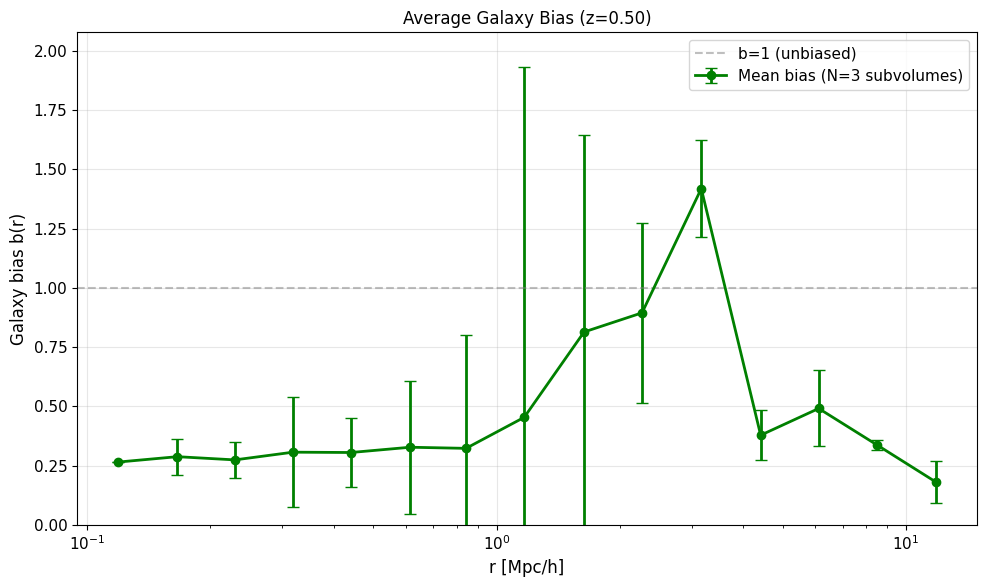

In [ ]:
# Plot average bias data over subvolumes
if avg_result is not None:
    r = avg_result['r'].to_numpy()
    xi_gal = avg_result['xi_gal'].to_numpy() - 1  # Convert from (1+xi) to xi
    xi_dm = avg_result['xi_dm'].to_numpy() - 1
    
    # Compute bias correctly: b(r) = sqrt(xi_gal / xi_dm)
    bias = np.sqrt(xi_gal / xi_dm)
    bias_std = avg_result['bias_std'].to_numpy()
    
    # Create summary table
    mask = np.isfinite(bias)
    print(f"\n{'r [Mpc/h]':>12}  {'bias':>10}  {'std':>10}")
    print("-" * 35)
    for i in range(len(r)):
        if mask[i]:
            print(f"{r[i]:12.2f}  {bias[i]:10.3f}  {bias_std[i]:10.3f}")
    
    # Plot with error bars
    plt.figure(figsize=(10, 6))
    plt.errorbar(r[mask], bias[mask], yerr=bias_std[mask], 
                 fmt='o-', color='green', markersize=6, linewidth=2,
                 capsize=4, label=f'Mean bias (N={avg_result.attrs.get("n_used")} subvolumes)')
    plt.axhline(1, color='gray', linestyle='--', alpha=0.5, label='b=1 (unbiased)')
    plt.xscale('log')
    plt.xlabel('r [Mpc/h]', fontsize=12)
    plt.ylabel('Galaxy bias b(r)', fontsize=12)
    plt.title(f'Average Galaxy Bias (z={avg_result.attrs.get("z"):.2f})', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()

## Redshift Evolution

In [ ]:
# Fetch galaxy bias data at multiple redshifts
iz_nums = [271, 207]  # z=0.0 and z=0.496
example_ivol = 100

print("Computing galaxy bias evolution with redshift")
print(f"Snapshots: iz{iz_nums[0]} (z=0.0), iz{iz_nums[1]} (z≈0.5)\n")

redshift_results = []
for iz_num in iz_nums:
    snap_path = str(base_dir / f'iz{iz_num}')
    tree_file = tree_file_for(iz_num, example_ivol)
    res = compute_galaxy_bias(
        iz_path=snap_path,
        ivol=example_ivol,
        tree_file=str(tree_file),
        rbins=rbins,
        nthreads=4,
        mhalo_min=mhalo_min,
    )
    if res is not None:
        redshift_results.append(res)
        print(f"✓ iz{iz_num}: z={res.attrs.get('z'):.3f}, N_gal={res.attrs.get('ngal')}, N_halo={res.attrs.get('nhalo')}")
    else:
        print(f"✗ iz{iz_num}: failed")

if len(redshift_results) > 0:
    print(f"\nSuccessfully computed {len(redshift_results)}/2 snapshots")
else:
    print("No successful computations")

Computing galaxy bias evolution with redshift
Snapshots: iz271 (z=0.0), iz207 (z≈0.5)

✗ iz271: failed


Traceback (most recent call last):
  File "/cosma/home/durham/dc-hick2/galform_analysis/src/galform_analysis/analysis/correlation/dm_correlation.py", line 430, in dm_correlation_from_tree_file
    pos, boxsize, redshift, unit_hint = _load_halo_positions_from_hdf5(
  File "/cosma/home/durham/dc-hick2/galform_analysis/src/galform_analysis/analysis/correlation/dm_correlation.py", line 166, in _load_halo_positions_from_hdf5
    raise FileNotFoundError(f"Merger tree file not found: {tree_file}")
FileNotFoundError: Merger tree file not found: /cosma5/data/jch/Galform/Merger_Trees/P-Millennium/Updated_Trees/all_snaps/treedir_271/tree_271.100.hdf5


✓ iz207: z=0.496, N_gal=6152, N_halo=250

Successfully computed 1/2 snapshots


/tmp/ipykernel_2871009/3848468965.py:15: RuntimeWarning: invalid value encountered in sqrt
  bias = np.sqrt(xi_gal / xi_dm)


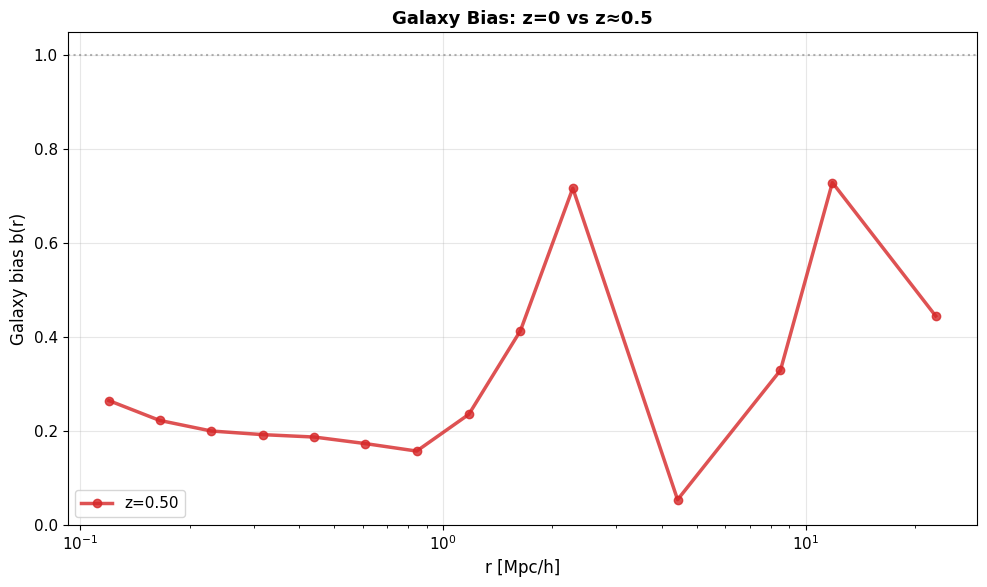

In [ ]:
# Plot galaxy bias evolution with redshift
if len(redshift_results) > 0:
    plt.figure(figsize=(10, 6))
    
    colors = ['#d62728', '#1f77b4']  # Red for z=0, blue for z~0.5
    linestyles = ['-', '--']
    markers = ['o', 's']
    
    for i, res in enumerate(redshift_results):
        r = res["r"].to_numpy()
        xi_gal = res["xi_gal"].to_numpy() - 1  # Convert from (1+xi) to xi
        xi_dm = res["xi_dm"].to_numpy() - 1
        
        # Compute bias correctly: b(r) = sqrt(xi_gal / xi_dm)
        bias = np.sqrt(xi_gal / xi_dm)
        mask = np.isfinite(bias)
        z = res.attrs.get("z")
        label = f"z={z:.2f}" if z is not None else "z=unknown"
        
        plt.semilogx(r[mask], bias[mask], linestyle=linestyles[i], marker=markers[i],
                     color=colors[i], label=label, markersize=6, linewidth=2.5, alpha=0.8)
    
    plt.axhline(1, color='gray', linestyle=':', alpha=0.6, linewidth=1.5)
    plt.xlabel('r [Mpc/h]', fontsize=12)
    plt.ylabel('Galaxy bias b(r)', fontsize=12)
    plt.title('Galaxy Bias: z=0 vs z≈0.5', fontsize=13, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11, loc='best')
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()
else:
    print("No redshift results to plot")